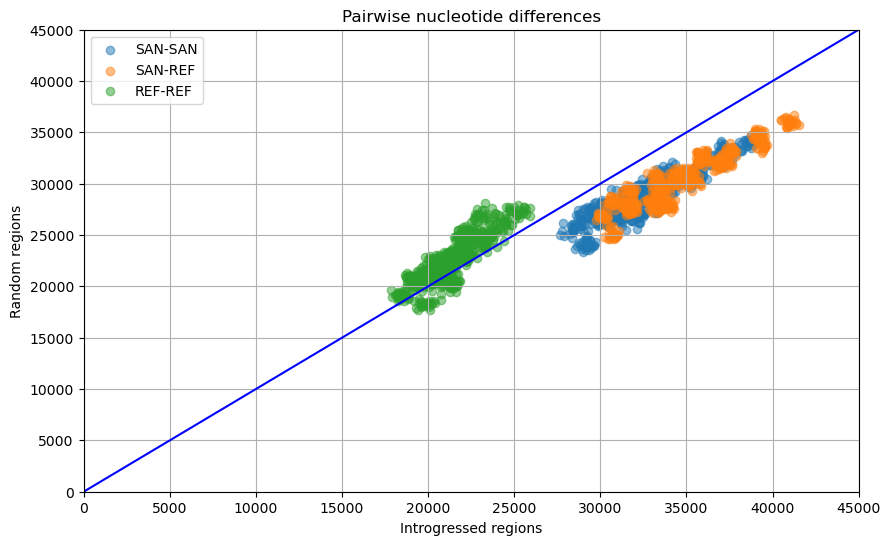

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace 'file1.csv', 'file2.csv', 'file3.csv', and 'file4.csv' with your actual file names
file1 = 'total_diff_sums_target_individuals.csv'
file2 = 'random_diff_sums_target_individuals.csv'
file3 = 'total_diff_sums_all_ref_individuals.csv'
file4 = 'random_diff_sums_all_ref_individuals.csv'

# Define groups of individuals for the first pair of files
group1 = ["KSP062", "KSP063", "KSP065", "KSP067", "KSP069", "KSP092", "KSP096", "KSP103", "KSP105", "KSP106", "KSP111", "KSP116", "KSP124", "KSP134", "KSP137", "KSP139", "KSP140", "KSP146", "KSP150", "KSP152", "KSP154", "KSP155", "KSP224", "KSP225", "KSP228"]
group2 = ["HG02568", "HG02922", "HG03052", "HGDP_HGDP00927", "HGDP_HGDP01284", "SGDP_LP6005441-DNA_E07", "SGDP_LP6005441-DNA_F07", "SGDP_LP6005442-DNA_A02", "SGDP_LP6005442-DNA_A10", "SGDP_LP6005442-DNA_B02", "SGDP_LP6005442-DNA_B10", "SGDP_LP6005442-DNA_G10", "SGDP_LP6005442-DNA_G11", "SGDP_LP6005442-DNA_H10", "SGDP_SS6004475", "SGDP_SS6004470", "HGDP_DNK02", "NA19017", "PNP010", "PNP011", "PNP012", "PNP013", "PNP014", "PNP030", "PNP031"]

# Create a column 'Group' to categorize individuals for the first pair
df1['Group'] = df1['Individual'].apply(lambda x: 'Group1' if x in group1 else ('Group2' if x in group2 else 'Group3'))
df2['Group'] = df2['Individual'].apply(lambda x: 'Group1' if x in group1 else ('Group2' if x in group2 else 'Group3'))

# Create a column 'Group' to categorize individuals for the third group
df3['Group'] = 'Group3'
df4['Group'] = 'Group3'

# Drop the 'Individual' column
df1 = df1.drop(columns=['Individual'])
df2 = df2.drop(columns=['Individual'])
df3 = df3.drop(columns=['Individual'])
df4 = df4.drop(columns=['Individual'])

# Flatten the data into a single list of values and groups for the first pair
x_values1 = df1.drop(columns=['Group']).values.flatten()
y_values1 = df2.drop(columns=['Group']).values.flatten()
groups1 = df1['Group'].values.repeat(df1.shape[1] - 1)

# Flatten the data into a single list of values and groups for the third group
x_values2 = df3.drop(columns=['Group']).values.flatten()
y_values2 = df4.drop(columns=['Group']).values.flatten()
groups2 = df3['Group'].values.repeat(df3.shape[1] - 1)

# Combine the values and groups from both pairs
x_values = pd.concat([pd.Series(x_values1), pd.Series(x_values2)])
y_values = pd.concat([pd.Series(y_values1), pd.Series(y_values2)])
groups = pd.concat([pd.Series(groups1), pd.Series(groups2)])

# Drop NaN values
valid_idx = ~pd.isna(x_values) & ~pd.isna(y_values)
x_values = x_values[valid_idx]
y_values = y_values[valid_idx]
groups = groups[valid_idx]

# Create a scatter plot
plt.figure(figsize=(10, 6))
labels = {
    'Group1': 'SAN-SAN',
    'Group2': 'SAN-REF',
    'Group3': 'REF-REF'
}

for group in ['Group1', 'Group2', 'Group3']:
    idx = groups == group
    plt.scatter(x_values[idx], y_values[idx], alpha=0.5, label=labels[group])

max_value = max(max(x_values), max(y_values))
plt.plot([0, max_value*1.2], [0, max_value*1.2], 'b-')

plt.title('Pairwise nucleotide differences')
plt.xlabel('Introgressed regions')
plt.ylabel('Random regions')
plt.legend()
plt.grid(True)
plt.xlim(0, 45000)
plt.ylim(0, 45000)
plt.show()
